<a href="https://colab.research.google.com/github/Shumail-Khan/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Heart Disease Prediction

#### Objective:
Build a model to predict whether a person is at risk of heart disease based on their health data.
#### Dataset:
Heart Disease UCI Dataset (available on Kaggle)

Instructions:
<ul>
  <li>Clean the dataset (handle missing values if any).</li>
  <li>Perform Exploratory Data Analysis (EDA) to understand trends.</li>
  <li>Train a classification model (Logistic Regression or Decision Tree).</li>
  <li>Evaluate using metrics: accuracy, ROC curve, and confusion matrix.</li>
  <li>Highlight important features affecting prediction.</li>
</ul>

Skills:
<ul>
  <li>Binary classification</li>
  <li>Medical data understanding and interpretation</li>
  <li>Model evaluation using ROC-AUC and confusion matrix</li>
  <li>Feature importance analysis</li>
</ul>

Dataset

Use the Heart Disease UCI Dataset

Direct link:

https://www.kaggle.com/code/zeeshanyounas001/heart-disease-uci/

Steps:
<ul>
  <li>Download heart.csv</li>
  <li>Place it in your project folder</li>
</ul>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

# Drop unnecessary columns
df.drop(['id', 'dataset'], axis=1, inplace=True)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.drop('num', axis=1, inplace=True)

In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


In [5]:
df.replace('?', np.nan, inplace=True)

# Convert numeric columns
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

/tmp/ipykernel_22020/2841084665.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    float64
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    float64
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   target                    920 non-null    int64  
 9   sex_Male                  920 non-null    bool   
 10  cp_atypical angina        920 non-null    bool   
 11  cp_non-anginal            920 non-null    bool   
 12  cp_typical angina         920 non-null    bool   
 13  restecg_normal            920 non-null    bool   
 14  restecg_st

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,0.150000,137.692391,0.366304,0.853261,0.227174,0.553261
std,9.424685,18.451300,109.040171,0.357266,25.145235,0.482056,1.058049,0.628936,0.497426
min,28.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,140.000000,0.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,0.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000


### Countplot

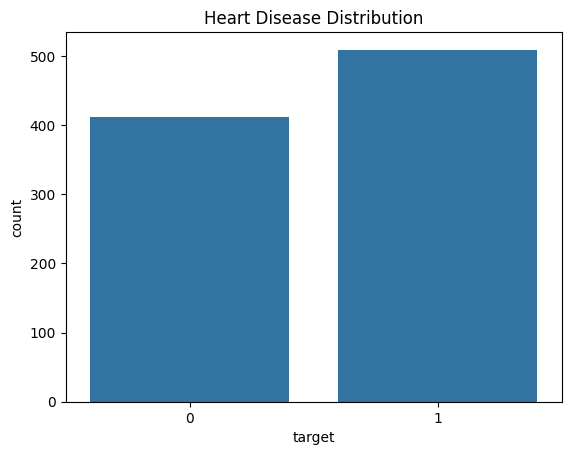

In [8]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

### Correlation Heatmap

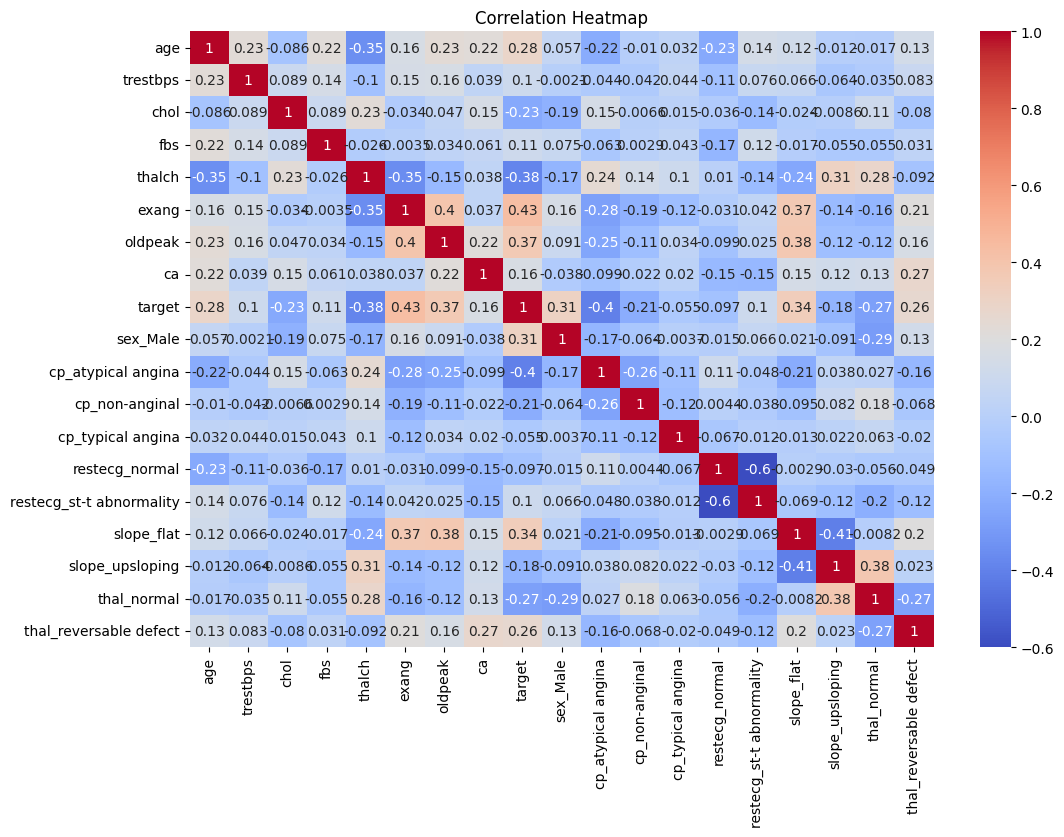

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### Data Splitting

In [10]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Model Training

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

#### Accuracy

In [13]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Logistic Regression: 0.8043478260869565
Decision Tree: 0.7771739130434783


#### Confusion Matrix

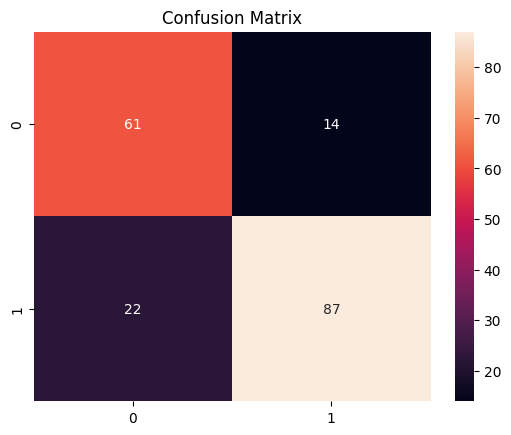

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#### ROC Curve

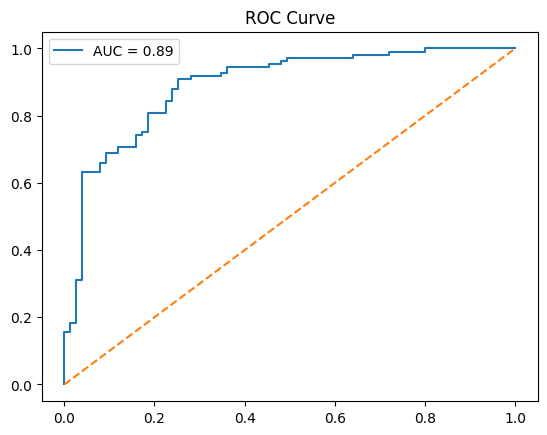

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.show()

### Feature Importance
##### Logistic Regression

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr.coef_[0]
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

                     Feature  Importance
8                   sex_Male    0.583205
7                         ca    0.551825
6                    oldpeak    0.468324
5                      exang    0.372744
14                slope_flat    0.372369
3                        fbs    0.144010
13  restecg_st-t abnormality    0.141038
0                        age    0.126096
17    thal_reversable defect    0.090349
1                   trestbps    0.082937


#### Decision Tree

In [17]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

               Feature  Importance
5                exang    0.346285
2                 chol    0.194595
9   cp_atypical angina    0.087921
7                   ca    0.083347
8             sex_Male    0.069332
4               thalch    0.063980
16         thal_normal    0.035701
10      cp_non-anginal    0.033830
1             trestbps    0.024724
0                  age    0.023820
